Análisis de la base de datos

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_validate, ParameterGrid, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score,f1_score, precision_score ,recall_score, mean_squared_error, mean_absolute_error, median_absolute_error, confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [6]:
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [7]:
df.dtypes

Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


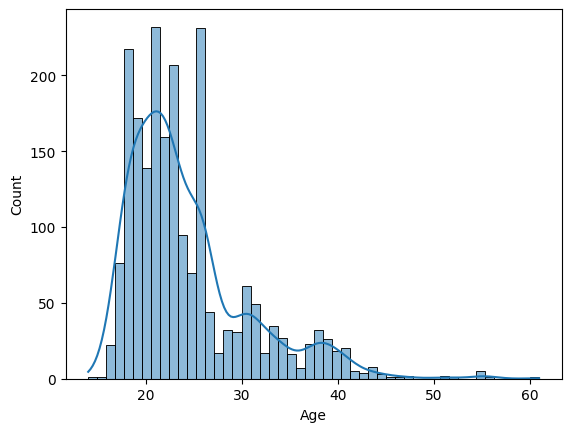

In [9]:
sns.histplot(df["Age"], kde=True)
plt.show()

<Axes: xlabel='Age'>

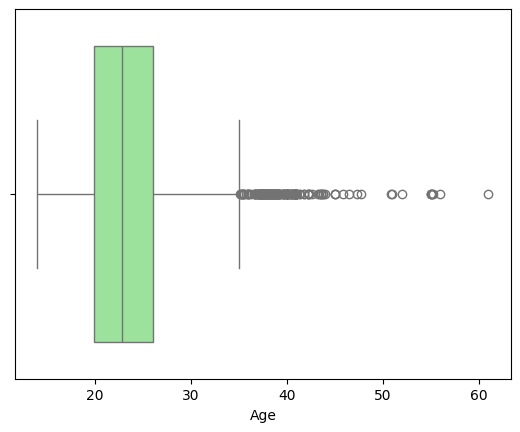

In [10]:
sns.boxplot(x=df.Age, color="lightgreen")

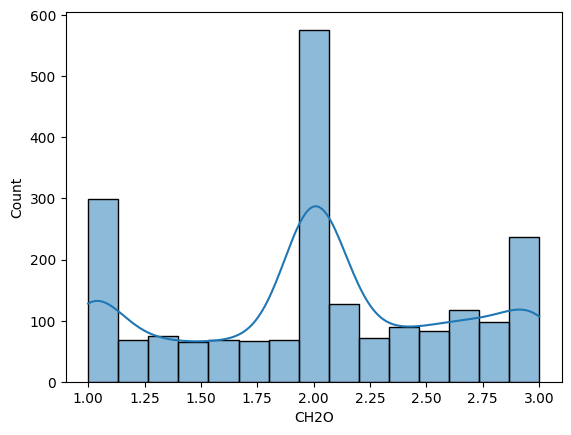

In [11]:
sns.histplot(df["CH2O"], kde=True)
plt.show()

<Axes: xlabel='CH2O'>

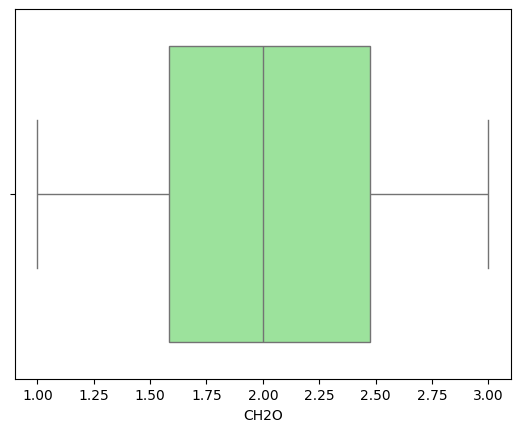

In [12]:
sns.boxplot(x=df.CH2O, color="lightgreen")

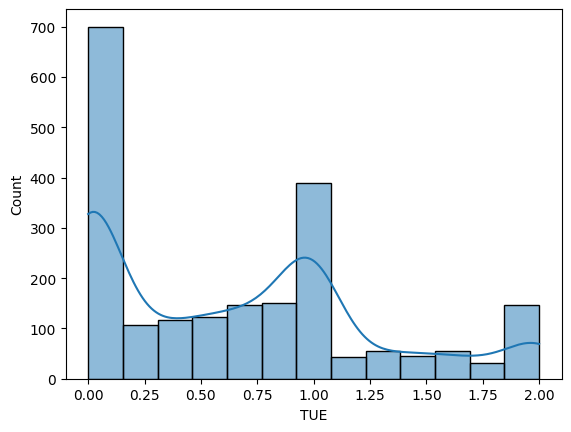

In [13]:
sns.histplot(df["TUE"], kde=True)
plt.show()

<Axes: xlabel='TUE'>

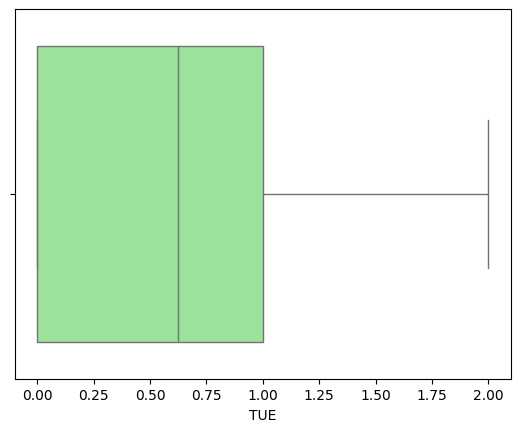

In [14]:
sns.boxplot(x=df.TUE, color="lightgreen")

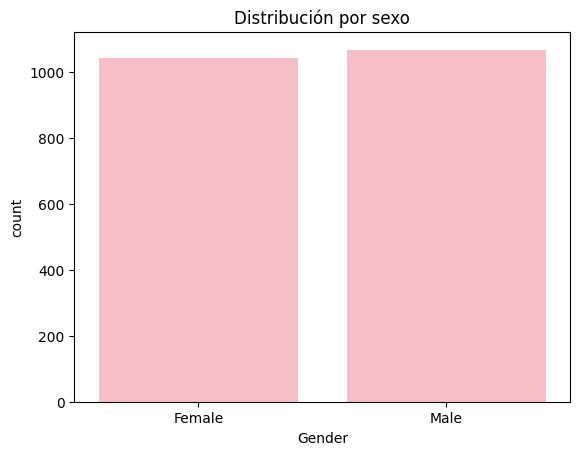

In [15]:
sns.countplot(data=df, x="Gender", color="lightpink")
plt.title("Distribución por sexo")
plt.show()

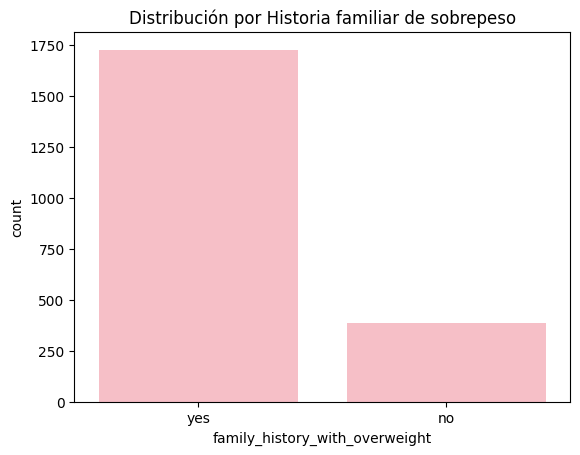

In [16]:
sns.countplot(data=df, x="family_history_with_overweight", color="lightpink")
plt.title("Distribución por Historia familiar de sobrepeso")
plt.show()

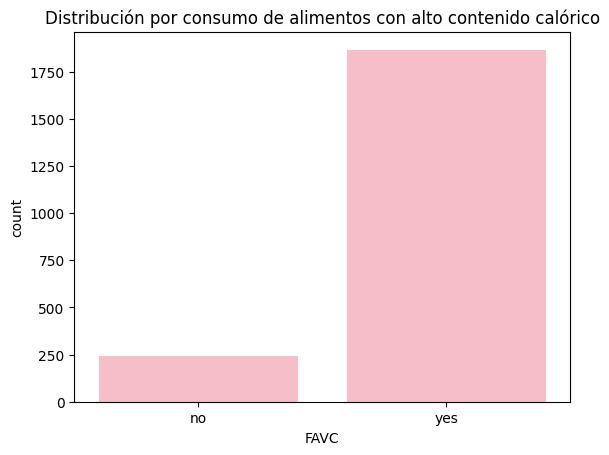

In [17]:
sns.countplot(data=df, x="FAVC", color="lightpink")
plt.title("Distribución por consumo de alimentos con alto contenido calórico")
plt.show()

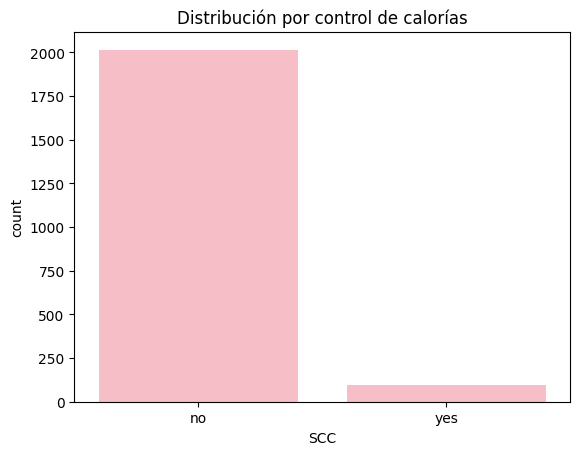

In [18]:
sns.countplot(data=df, x="SCC", color="lightpink")
plt.title("Distribución por control de calorías")
plt.show()

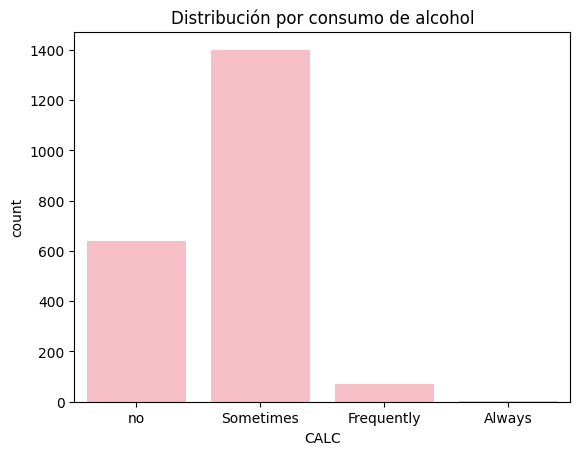

In [19]:
sns.countplot(data=df, x="CALC", color="lightpink")
plt.title("Distribución por consumo de alcohol")
plt.show()

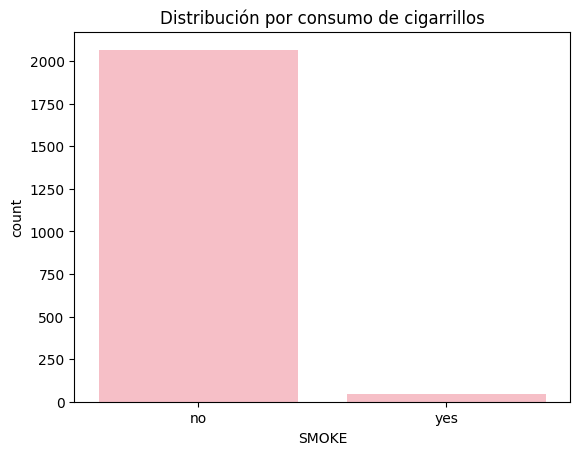

In [20]:
sns.countplot(data=df, x="SMOKE", color="lightpink")
plt.title("Distribución por consumo de cigarrillos")
plt.show()

In [21]:
cat = df.select_dtypes(include = ["str"]).columns.tolist()
df[cat].head(1)

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight


In [22]:
num=df.select_dtypes(include = ['float64']).columns.tolist()
df[num].head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0


In [23]:
corr = df[["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]].corr()
corr

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


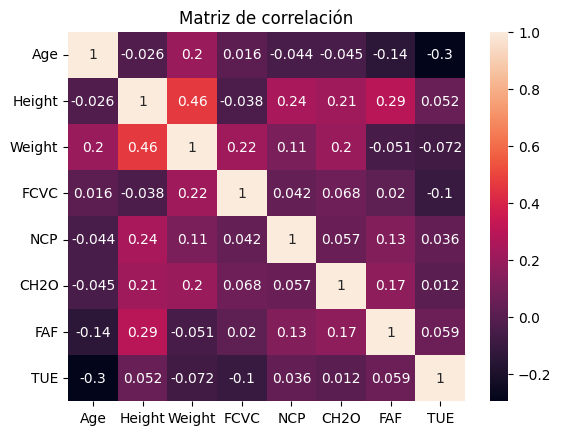

In [24]:
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

In [25]:
df.groupby('NObeyesdad').NObeyesdad.count().sort_values(ascending=False)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64

In [26]:
num.remove("Height")

In [27]:
cat.remove('NObeyesdad')
cat

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS']

In [28]:
df["NObeyesdad"] = LabelEncoder().fit_transform(df["NObeyesdad"])
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,1
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,1
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,1
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,5
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,6


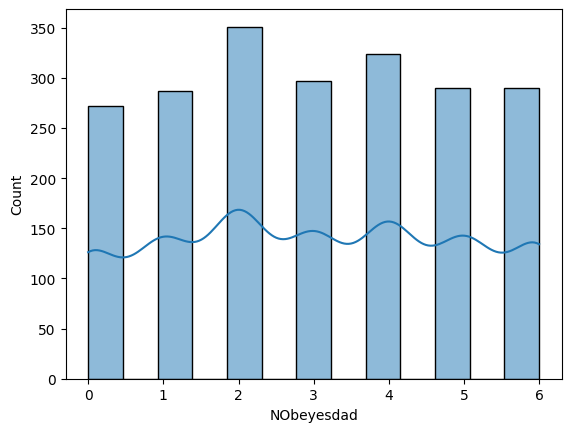

In [29]:
sns.histplot(df["NObeyesdad"], kde=True)
plt.show()

In [30]:
df =pd.get_dummies(df, drop_first=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2111 non-null   float64
 1   Height                              2111 non-null   float64
 2   Weight                              2111 non-null   float64
 3   FCVC                                2111 non-null   float64
 4   NCP                                 2111 non-null   float64
 5   CH2O                                2111 non-null   float64
 6   FAF                                 2111 non-null   float64
 7   TUE                                 2111 non-null   float64
 8   NObeyesdad                          2111 non-null   int64  
 9   Gender_Male                         2111 non-null   bool   
 10  family_history_with_overweight_yes  2111 non-null   bool   
 11  FAVC_yes                            2111 non-null   bo

In [31]:
df.head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,1,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,1,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,5,True,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,6,True,...,False,False,False,False,True,False,False,False,True,False


In [32]:
X = df.drop(columns=['NObeyesdad', 'Height'])
y = df['NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y.values.reshape(-1,1), train_size=0.8, random_state=0, shuffle=True)
X

,Age,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.000000,64.000000,2.0,3.0,2.000000,0.000000,1.000000,False,True,False,...,False,False,False,False,False,True,False,False,True,False
1,21.000000,56.000000,3.0,3.0,3.000000,3.000000,0.000000,False,True,False,...,False,True,True,False,True,False,False,False,True,False
2,23.000000,77.000000,2.0,3.0,2.000000,2.000000,1.000000,True,True,False,...,False,False,False,True,False,False,False,False,True,False
3,27.000000,87.000000,3.0,3.0,2.000000,2.000000,0.000000,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,22.000000,89.800000,2.0,1.0,2.000000,0.000000,0.000000,True,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,131.408528,3.0,3.0,1.728139,1.676269,0.906247,False,True,True,...,False,False,False,False,True,False,False,False,True,False
2107,21.982942,133.742943,3.0,3.0,2.005130,1.341390,0.599270,False,True,True,...,False,False,False,False,True,False,False,False,True,False
2108,22.524036,133.689352,3.0,3.0,2.054193,1.414209,0.646288,False,True,True,...,False,False,False,False,True,False,False,False,True,False
2109,24.361936,133.346641,3.0,3.0,2.852339,1.139107,0.586035,False,True,True,...,False,False,False,False,True,False,False,False,True,False


In [33]:
scaler = MinMaxScaler()
X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

X_train.head(2)

,Age,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
1295,0.513805,0.303445,0.500000,0.666667,0.137387,0.000000,0.0,False,True,True,...,False,False,False,False,True,False,False,False,False,False
1627,0.560984,0.524993,0.640982,0.923460,0.000000,0.443506,0.0,True,True,True,...,False,False,False,False,False,True,False,False,False,False


### **Modelos de ensamble basados en árboles**

**Random Forest**

In [34]:
resultados = []
for trees in range(10,101, 10):
    for features in range(12,17,1):
        modelo_rf = RandomForestClassifier(n_estimators=trees,criterion='entropy',max_features=features, min_samples_leaf=3, random_state=0)
        modelo_rf.fit(X_train, y_train)
        
        y_pred_rf = modelo_rf.predict(X_test)
        Yest = modelo_rf.predict(X_train)
        
        acc_test  = accuracy_score(y_test.ravel(), y_pred_rf)
        acc_train = accuracy_score(y_train.ravel(), Yest)

        resultados.append({
            'trees': trees,
            'features': features,
            'acc_train': acc_train,
            'acc_test':  acc_test
        })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(['acc_test', 'trees'], ascending=[False, True]).reset_index(drop=True)

,trees,features,acc_train,acc_test
0,30,12,0.984005,0.931442
1,70,12,0.985782,0.931442
2,80,12,0.986374,0.931442
3,90,12,0.985190,0.931442
4,100,12,0.984597,0.931442
5,70,14,0.984597,0.929078
6,40,12,0.986374,0.926714
7,50,12,0.985782,0.926714
8,90,15,0.980450,0.926714
9,100,13,0.985782,0.926714


trees        30.000000
features     12.000000
acc_train     0.984005
acc_test      0.931442
Name: 10, dtype: float64


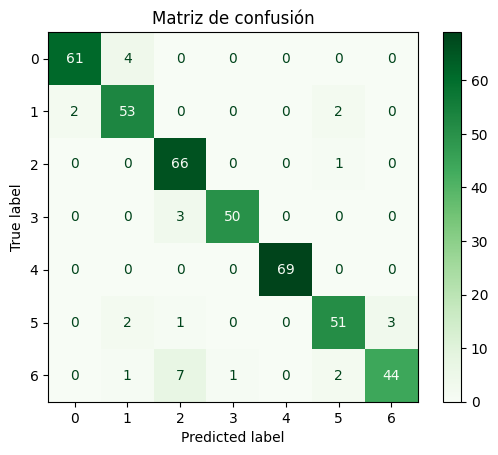

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        65
           1       0.88      0.93      0.91        57
           2       0.86      0.99      0.92        67
           3       0.98      0.94      0.96        53
           4       1.00      1.00      1.00        69
           5       0.91      0.89      0.90        57
           6       0.94      0.80      0.86        55

    accuracy                           0.93       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.93      0.93      0.93       423



In [35]:
mejor =df_resultados.loc[df_resultados['acc_test'].idxmax()]
print(mejor)
mejor_modelo_rf = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion='entropy',max_features=int(mejor['features']), min_samples_leaf=3, random_state=0)
mejor_modelo_rf.fit(X_train, y_train)
y_pred_final = mejor_modelo_rf.predict(X_test) 

mc = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf.classes_)
disp.plot(cmap='Greens')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test, y_pred_final))

In [36]:
print("Validación sin ninguna técnica:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1:       {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro'):.4f}")

Validación sin ninguna técnica:
Accuracy: 0.9314
F1:       0.9290
Recall:   0.9274
Precision: 0.9337


**Validación con cross validation**

In [37]:
X_completo = X
y_completo = y
scaler = MinMaxScaler()
X_completo[num] = scaler.fit_transform(X_completo[num])
X_completo.head(5)


,Age,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.148936,0.186567,0.5,0.666667,0.5,0.000000,0.5,False,True,False,...,False,False,False,False,False,True,False,False,True,False
1,0.148936,0.126866,1.0,0.666667,1.0,1.000000,0.0,False,True,False,...,False,True,True,False,True,False,False,False,True,False
2,0.191489,0.283582,0.5,0.666667,0.5,0.666667,0.5,True,True,False,...,False,False,False,True,False,False,False,False,True,False
3,0.276596,0.358209,1.0,0.666667,0.5,0.666667,0.0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,0.170213,0.379104,0.5,0.000000,0.5,0.000000,0.0,True,False,False,...,False,False,False,False,True,False,False,False,True,False


In [38]:
cv = 21
scoring = ['accuracy', 'recall_macro', 'f1_macro', 'precision_macro']

entries = []
accuracies = cross_validate(mejor_modelo_rf, X_completo, y_completo, cv=cv, scoring=scoring)
    
cv_df = pd.DataFrame({
    'fold_idx': range(cv),
    'accuracy':  accuracies['test_accuracy'],
    'recall':    accuracies['test_recall_macro'],
    'f1':        accuracies['test_f1_macro'],
    'precision': accuracies['test_precision_macro']
})
        
print(cv_df)

    fold_idx  accuracy    recall        f1  precision
0          0  0.722772  0.716124  0.717262   0.753997
1          1  0.782178  0.775307  0.783182   0.825062
2          2  0.762376  0.759125  0.754422   0.785788
3          3  0.831683  0.827806  0.823030   0.843583
4          4  0.900990  0.895604  0.897194   0.906901
5          5  1.000000  1.000000  1.000000   1.000000
6          6  0.930693  0.931388  0.927360   0.935334
7          7  0.970297  0.968603  0.969418   0.971655
8          8  0.920792  0.920399  0.917172   0.919411
9          9  0.910891  0.912780  0.911578   0.921664
10        10  0.970297  0.968603  0.969418   0.971655
11        11  0.930000  0.932173  0.928525   0.933078
12        12  0.970000  0.972989  0.971015   0.970748
13        13  0.940000  0.940807  0.940761   0.944409
14        14  0.970000  0.967818  0.969235   0.973016
15        15  0.980000  0.978807  0.978778   0.980272
16        16  0.970000  0.967033  0.967542   0.974790
17        17  0.970000  0.96

In [39]:
main_accuracy = "Accuracy promedio: ", cv_df['accuracy'].mean().__round__(4)
main_recall = "Recall promedio: ", cv_df['recall'].mean().__round__(4)
main_f1 = "F1 promedio: ", cv_df['f1'].mean().__round__(4)
main_precision = "Precision promedio: ", cv_df['precision'].mean().__round__(4)

In [40]:
tabla_resultados = pd.DataFrame(columns=['Modelo', 'Accuracy', 'Recall', 'F1', 'Precision'])
tabla_resultados = pd.concat([tabla_resultados,
                       pd.DataFrame([{'Modelo': 'Random forest',
                                      'Accuracy': main_accuracy[1],
                                      'Recall': main_recall[1],
                                      'F1': main_f1[1],
                                      'Precision': main_precision[1]}])]
                      , ignore_index=True)

tabla_resultados

,Modelo,Accuracy,Recall,F1,Precision
0,Random forest,0.9192,0.9173,0.9168,0.927


**Gradient Boosting**

In [41]:
modelo_gb = GradientBoostingClassifier(random_state=0)  
modelo_gb.fit(X_train, y_train)
y_pred_gb = modelo_gb.predict(X_test)

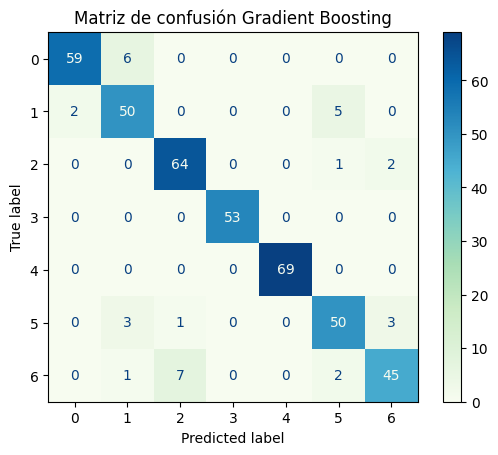

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        65
           1       0.83      0.88      0.85        57
           2       0.89      0.96      0.92        67
           3       1.00      1.00      1.00        53
           4       1.00      1.00      1.00        69
           5       0.86      0.88      0.87        57
           6       0.90      0.82      0.86        55

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423



In [42]:
mc_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=mc_gb, display_labels=modelo_gb.classes_)
disp.plot(cmap='GnBu')
plt.title("Matriz de confusión Gradient Boosting")
plt.show()
print(classification_report(y_test, y_pred_gb))

**Encontrar los mejores hiperparámetros con GridSearchCV**

In [43]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
grid_parametros = {'learning_rate': [0.01, 0.1, 0.2], 
                   'n_estimators': [50, 100, 150]}

cv = 10

modelo_gb_grid = GridSearchCV(estimator=modelo_gb, 
                              param_grid=grid_parametros, 
                              cv=cv, 
                              scoring=scoring,
                              refit='accuracy', 
                              return_train_score = True, 
                              verbose=4)


modelo_gb_grid.fit(X_completo, y_completo)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.787, test=0.590) f1: (train=0.775, test=0.597) precision: (train=0.791, test=0.636) recall: (train=0.781, test=0.581) total time=   0.9s
[CV 2/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.796, test=0.716) f1: (train=0.785, test=0.687) precision: (train=0.807, test=0.707) recall: (train=0.790, test=0.710) total time=   0.8s
[CV 3/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.767, test=0.739) f1: (train=0.756, test=0.718) precision: (train=0.769, test=0.733) recall: (train=0.761, test=0.732) total time=   0.8s
[CV 4/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.783, test=0.749) f1: (train=0.773, test=0.739) precision: (train=0.782, test=0.753) recall: (train=0.778, test=0.742) total time=   0.8s
[CV 5/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.781, test=0.791) f1: (train=0.772, test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [44]:
resultados = pd.DataFrame(modelo_gb_grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_accuracy', ascending = False) \
    .head(4)
    
    

,param_learning_rate,param_n_estimators,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
8,0.2,150,0.909150,0.090341,1.000000,0.000000,0.904589,0.095834,1.000000,0.000000,0.921502,0.067630,1.000000,0.000000,0.906190,0.094274,1.000000,0.000000
7,0.2,100,0.907735,0.091230,0.999947,0.000158,0.903864,0.095444,0.999945,0.000165,0.919994,0.068062,0.999945,0.000165,0.904991,0.094812,0.999945,0.000164
5,0.1,150,0.907259,0.091710,0.998421,0.000815,0.903756,0.095816,0.998386,0.000826,0.919513,0.069510,0.998377,0.000830,0.904463,0.095340,0.998401,0.000821
4,0.1,100,0.902041,0.088144,0.991579,0.003087,0.898033,0.092699,0.991356,0.003168,0.912972,0.068414,0.991403,0.003145,0.899207,0.091828,0.991335,0.003179


In [45]:
modelo_gb_grid.best_params_

{'learning_rate': 0.2, 'n_estimators': 150}

In [46]:
mejores_parametros = modelo_gb_grid.best_params_
splits= [2,3]
leaf= [1,2,3]
resultados = []

for i in splits:
    for j in leaf:

        modelo_gb_refinado = GradientBoostingClassifier(
            learning_rate=mejores_parametros['learning_rate'],
            n_estimators=mejores_parametros['n_estimators'],
            min_samples_split=i,
            min_samples_leaf=j,
            random_state=0
        )

        modelo_gb_refinado.fit(X_train, y_train)

        y_pred_test = modelo_gb_refinado.predict(X_test)
        y_pred_train = modelo_gb_refinado.predict(X_train)

        resultados.append({
            'min_samples_split': i,
            'min_samples_leaf': j,
            'acc_test': accuracy_score(y_test, y_pred_test),
            'recall_test': recall_score(y_test, y_pred_test, average='macro'),
            'f1_test': f1_score(y_test, y_pred_test, average='macro'),
            'precision_test': precision_score(y_test, y_pred_test, average='macro') 
        })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(
    by=['acc_test', 'recall_test', 'f1_test', 'precision_test'],
    ascending=[False, False, False, False]
)
        


,min_samples_split,min_samples_leaf,acc_test,recall_test,f1_test,precision_test
2,2,3,0.924350,0.921952,0.922183,0.923283
5,3,3,0.924350,0.921952,0.922183,0.923283
1,2,2,0.921986,0.918981,0.919644,0.922585
4,3,2,0.921986,0.918981,0.919644,0.922585
3,3,1,0.914894,0.911770,0.912288,0.914729
0,2,1,0.910165,0.906576,0.907131,0.910358


In [47]:
df_resultados.iloc[0]

min_samples_split    2.000000
min_samples_leaf     1.000000
acc_test             0.910165
recall_test          0.906576
f1_test              0.907131
precision_test       0.910358
Name: 0, dtype: float64

In [48]:
tabla_resultados = pd.concat([tabla_resultados,
                       pd.DataFrame([{'Modelo': 'Gradient Boosting',
                                      'Accuracy': df_resultados.iloc[0]['acc_test'],
                                      'Recall': df_resultados.iloc[0]['recall_test'],
                                      'F1': df_resultados.iloc[0]['f1_test'],
                                      'Precision': df_resultados.iloc[0]['precision_test']}])]
                      , ignore_index=True)

In [49]:
tabla_resultados.drop_duplicates(inplace=True)

In [50]:
tabla_resultados

,Modelo,Accuracy,Recall,F1,Precision
0,Random forest,0.9192,0.9173,0.9168,0.927
1,Gradient Boosting,0.910165,0.906576,0.907131,0.910358


### **Módelo de Redes Neuronales**

In [51]:
iterations = [100, 200, 300]
resultados = []
for i in iterations:
    
    modelo_neuronal = MLPClassifier(max_iter=i, early_stopping=True, random_state=0)
    
    modelo_neuronal.fit(X_train, y_train)
    y_pred_neuronal = modelo_neuronal.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred_neuronal)
    recall = recall_score(y_test, y_pred_neuronal, average='macro')
    f1 = f1_score(y_test, y_pred_neuronal, average='macro')
    precision = precision_score(y_test, y_pred_neuronal, average='macro')
    
    resultados.append({
            'iteraciones': i,
            'acc_test': accuracy,
            'recall_test': recall,
            'f1_test': f1,
            'precision_test': precision
        })

df_resultados = pd.DataFrame(resultados)
df_resultados 

,iteraciones,acc_test,recall_test,f1_test,precision_test
0,100,0.749409,0.742626,0.735384,0.735672
1,200,0.749409,0.742626,0.735384,0.735672
2,300,0.749409,0.742626,0.735384,0.735672


In [52]:
modelo_neuronal.n_iter_

79

In [53]:
modelo_neuronal = MLPClassifier(early_stopping=True, random_state=0)
modelo_neuronal.fit(X_train, y_train)
y_pred_neuronal = modelo_neuronal.predict(X_test)

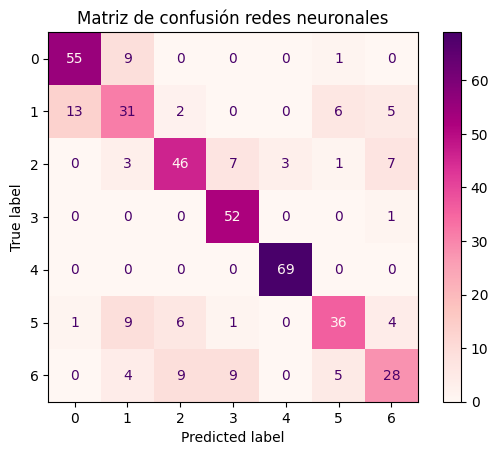

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        65
           1       0.55      0.54      0.55        57
           2       0.73      0.69      0.71        67
           3       0.75      0.98      0.85        53
           4       0.96      1.00      0.98        69
           5       0.73      0.63      0.68        57
           6       0.62      0.51      0.56        55

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.74      0.75      0.74       423



In [54]:
mc_gb = confusion_matrix(y_test, y_pred_neuronal)
disp = ConfusionMatrixDisplay(confusion_matrix=mc_gb, display_labels=modelo_neuronal.classes_)
disp.plot(cmap='RdPu')
plt.title("Matriz de confusión redes neuronales")
plt.show()
print(classification_report(y_test, y_pred_neuronal))

In [55]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_parametros = {'hidden_layer_sizes': [
                    (80,80,80,80),
                    (100,100,100,100)
                    ],
                   'activation': ['relu', 'tanh'],
                   'alpha': [0.0001, 0.001, 0.01]
                   }


modelo_neuronal_grid = GridSearchCV(estimator=modelo_neuronal, 
                              param_grid=grid_parametros, 
                              cv=cv, 
                              scoring=scoring,
                              refit='accuracy', 
                              return_train_score = True, 
                              verbose=4)


modelo_neuronal_grid.fit(X_completo, y_completo)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.934, test=0.846) f1: (train=0.933, test=0.841) precision: (train=0.937, test=0.843) recall: (train=0.933, test=0.843) total time=   0.8s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.930, test=0.820) f1: (train=0.929, test=0.818) precision: (train=0.932, test=0.820) recall: (train=0.929, test=0.820) total time=   0.7s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.875, test=0.808) f1: (train=0.874, test=0.802) precision: (train=0.874, test=0.815) recall: (train=0.876, test=0.807) total time=   0.4s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.882, test=0.858) f1: (train=0.879, test=0.855) precision: (train=0.879, test=0.855) recall: (train=0.880, test=0.855) total time

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80, ...), (100, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose

In [56]:
modelo_neuronal_grid.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (100, 100, 100, 100)}

In [57]:
modelo_neuronal_grid.best_score_

np.float64(0.8517427985613928)

In [58]:
resultados = pd.DataFrame(modelo_neuronal_grid.cv_results_)

columnas = [
    'params',
    'mean_test_accuracy',
    'mean_test_f1',
    'mean_test_precision',
    'mean_test_recall'
]

resultados[columnas].sort_values(
    by='mean_test_accuracy',
    ascending=False
)

,params,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
1,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.851743,0.848072,0.852230,0.849332
2,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.850788,0.848008,0.851918,0.849070
5,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.846056,0.842786,0.845873,0.842953
4,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.843685,0.840742,0.843018,0.841719
3,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.839418,0.835385,0.841157,0.835851
0,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.837988,0.834397,0.838601,0.836343
11,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.833254,0.828776,0.830580,0.831014
7,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.832780,0.828276,0.830164,0.830521
9,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.832780,0.828276,0.830164,0.830521
10,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.828992,0.823721,0.825840,0.826298


In [59]:
resultados.iloc[0]

mean_fit_time           0.65746
std_fit_time           0.157661
mean_score_time         0.00534
std_score_time         0.000553
param_activation           relu
                         ...   
split2_train_recall    0.876324
split3_train_recall    0.880063
split4_train_recall    0.894878
mean_train_recall      0.902674
std_train_recall       0.024011
Name: 0, Length: 68, dtype: object

In [71]:
tabla_resultados = pd.concat([tabla_resultados,
                       pd.DataFrame([{'Modelo': 'Redes Neuronales',
                                      'Accuracy': resultados.iloc[0]['mean_test_accuracy'],
                                      'Recall': resultados.iloc[0]['mean_test_recall'],
                                      'F1': resultados.iloc[0]['mean_test_f1'],
                                      'Precision': resultados.iloc[0]['mean_test_precision']}])]
                      , ignore_index=True)

In [72]:
tabla_resultados.drop_duplicates(inplace=True)

In [73]:
tabla_resultados 

,Modelo,Accuracy,Recall,F1,Precision
0,Random forest,0.9192,0.9173,0.9168,0.927
1,Gradient Boosting,0.910165,0.906576,0.907131,0.910358
2,Redes Neuronales,0.837988,0.836343,0.834397,0.838601
